# Final Model

This notebook constructs the final model we will use to find the relative premium for houses in each neghborhood of Chicago. Our final model is an XGBoost regressor.

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import json

In [2]:
data = pd.read_parquet(r"..\Data\sale_and_crime_data\chicago_sales_with_crime.parquet")

There are several features in our final data set which we will want to exclude. These include features which encode the relative location of the houses, since we want all of the contribution of the location to be concentrated in the community area feature. We also exclude variables which have little to no predictive value and those which are mostly missing. We point the reader to the Exploring Alternate Linear Regression Models notebook in the data folder for more information.

In [3]:
features_to_exclude = ["pin","is_multisale",'flood_fema_sfha', "sale_filter_same_sale_within_365", "sale_filter_less_than_10k", "single_v_multi_family", "zip_code",
                      "longitude", "latitude", "sale_date_parsed", "class", 'centroid_x_crs_3435', 'centroid_y_crs_3435', 'pin10', 'nearest_metra_route_dist_ft', 'nearest_new_construction_pin10',
                       "school_elementary_district_name",'nearest_golf_course_dist_ft', "school_secondary_district_name", "township_code",  "neighborhood_code",'sale_filter_deed_type', 'nearest_cta_route_dist_ft',
                                 'nearest_vacant_land_pin10','airport_noise_dnl','attic_finish','census_acs5_tract_geoid', 'nearest_neighbor_1_pin10','nearest_neighbor_2_pin10','nearest_neighbor_3_pin10','sale_date_parsed','sale_date', 'sale_year']
data = data.drop(columns = features_to_exclude)

In [4]:
cat_cols = ["type_of_residence", "construction_quality", "garage_size",
            "basement_type", "ext_wall_material", "repair_condition", "basement_finish",
            "central_heating", "central_air", "community_area"]

for col in cat_cols:
    data[col] = data[col].astype("category")

We will now import our tuned hyperparameters and build our model.

In [8]:
y=data["sale_price"]
features = list(data.columns)
features.remove("sale_price")
X=data[features]

with open("hyperparameters.json", "r") as f:
    hyperparams = json.load(f)
model = xgb.XGBRegressor(
    random_state=42, 
    enable_categorical=True, 
    tree_method="hist",
    **hyperparams
)
model.fit(
    X,y,
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5371444645609915
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [9]:
import matplotlib.pyplot as plt

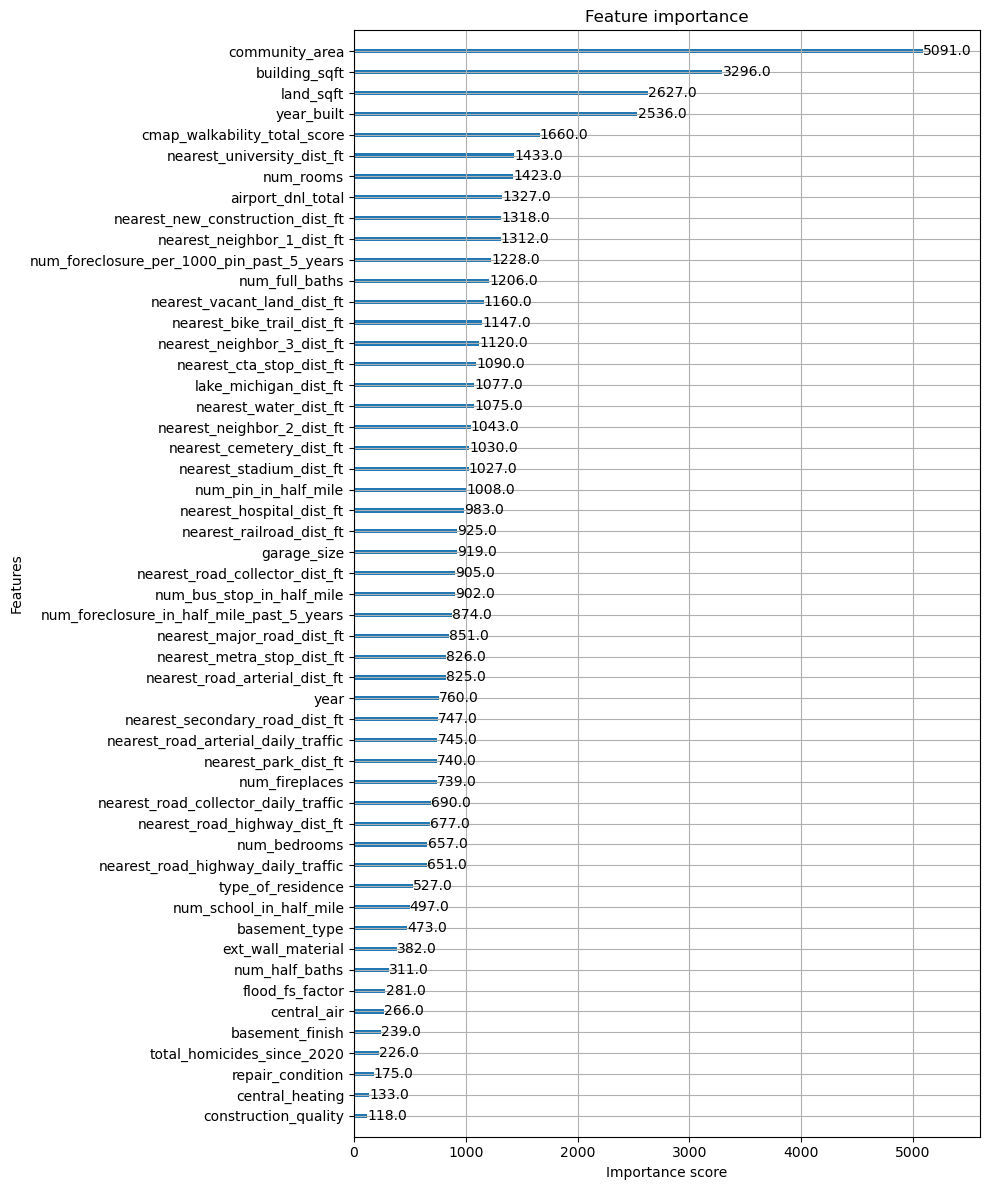

In [10]:
fig, ax = plt.subplots(figsize=(10, 12))  # wider and taller
xgb.plot_importance(model, ax=ax)
plt.tight_layout()
plt.show()

In [11]:
def categorical_pdp(model, X, feature, categories=None):
    """
    Compute partial dependence (marginal expected value) for a categorical feature.
    
    model: fitted XGBRegressor (enable_categorical=True)
    X: DataFrame used for prediction (same columns/dtypes as training)
    feature: name of the categorical column
    categories: optional list/order of categories to evaluate; defaults to all observed categories
    """
    if categories is None:
        categories = X[feature].cat.categories if hasattr(X[feature], "cat") else X[feature].unique()

    results = []
    X_temp = X.copy()

    for cat in categories:
        X_temp[feature] = cat
        # preserve categorical dtype/categories so xgboost doesn't complain
        X_temp[feature] = X_temp[feature].astype(X[feature].dtype)
        preds = model.predict(X_temp)
        results.append({"category": cat, "mean_prediction": preds.mean(), "std_prediction": preds.std()})

    return pd.DataFrame(results).sort_values("mean_prediction", ascending=False)

pdp_data = categorical_pdp(model, X, "community_area")
pdp_data["mean_prediction"]= pdp_data["mean_prediction"]-y.mean()
print(pdp_data.to_string(index=False))

 category  mean_prediction  std_prediction
        7    401488.781250   418385.468750
        8    332472.968750   387557.375000
        6    308566.531250   397041.968750
       24    282174.343750   374979.937500
        5    267508.968750   374648.593750
       41    251885.968750   368812.437500
       22    235193.156250   391046.031250
       77    234179.093750   358526.593750
       33    230627.468750   349615.750000
        3    200007.781250   335378.312500
        4    161545.468750   346965.687500
       21     99467.343750   299993.656250
       16     95705.656250   302909.625000
       14     92148.812500   320318.968750
       12     75689.218750   290410.718750
        1     59795.031250   265991.968750
       13     52193.625000   267131.906250
        9     50797.125000   277362.781250
        2     50754.718750   264087.937500
       76     50005.125000   256481.359375
       28     44060.656250   295575.093750
       31     38743.187500   293188.562500
       10  